![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# 03 | Hypotheses and Visualisation

*Project 1 — SQL: From Data to Insight*

**Dataset:** FAOSTAT


---
## 0. Setup

In [ ]:
import sys
sys.path.append("..")          # so `src` is importable from inside notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.functions import *

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

import sqlite3
from eralchemy2 import render_er
from IPython.display import Image, display
import plotly.express as px
from scipy.stats import pearsonr

In [59]:
DB_PATH = "../data/project.db"
con = sqlite3.connect(DB_PATH)
con.execute("PRAGMA foreign_keys = ON")

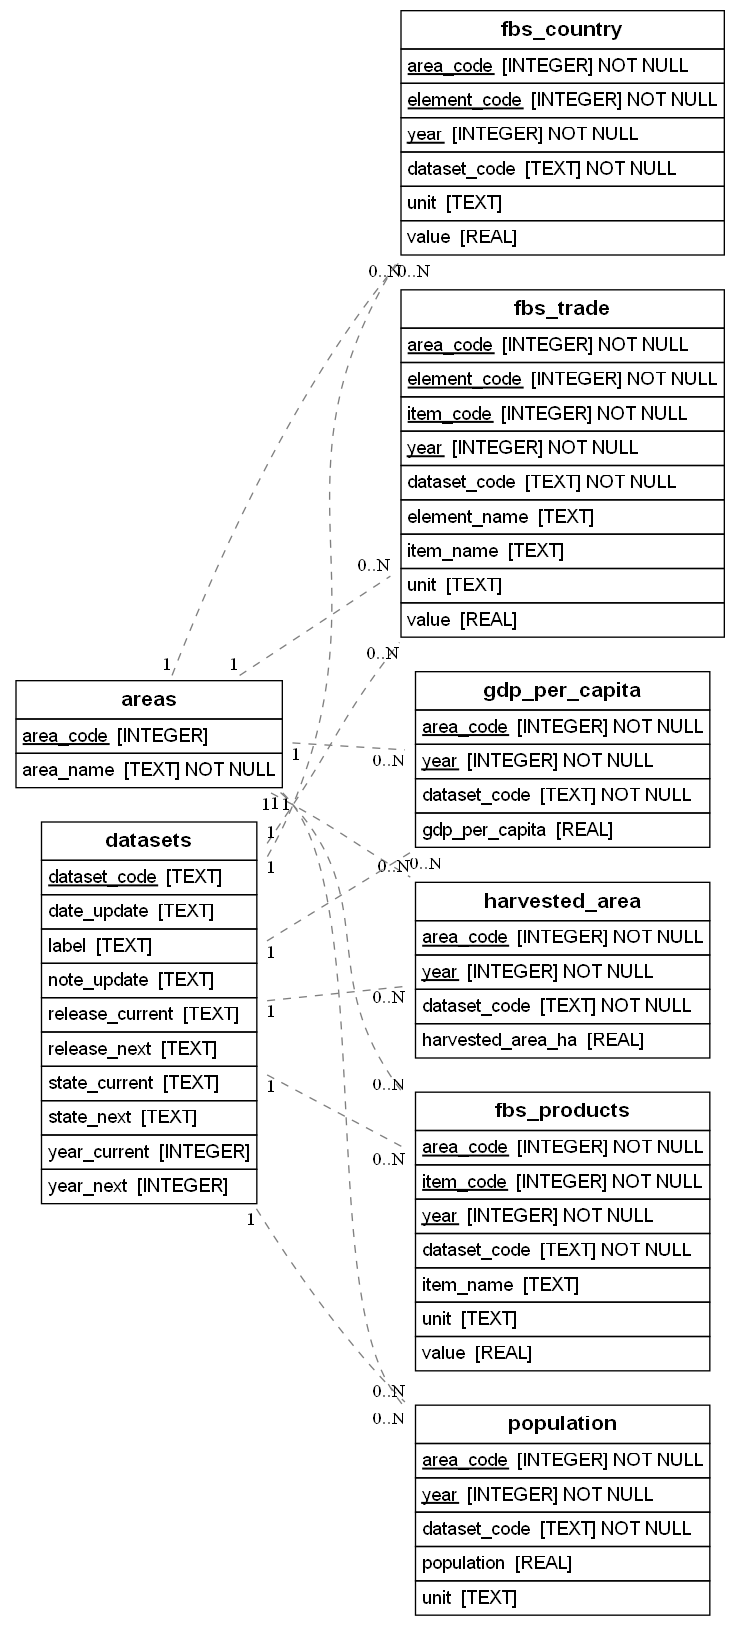

In [3]:
render_er("sqlite:///../data/project.db","../data/erd.png")
display(Image(filename="../data/erd.png"))

## PLAN:

---
## 1. The question



This project investigates differences in food availability across countries and how these patterns relate to agricultural resources, economic development, and food trade.

Research questions:

1. How does dietary energy supply (DES, kcal/person/day) differ across countries and regions, by year?

2. Which countries show the strongest increase or decline in DES over time?

3. Which food products/groups contribute most to DES, and how does this composition differ by year?

4. Which food products/groups show the strongest increase or decline in their contribution to DES over time?

5. Does harvested agricultural area per person relate to dietary energy supply, and which countries have relatively high harvested area per person but low DES?

6. Which food product groups are most associated with rising imports and declining domestic production as GDP per capita grows?

---
## 2. The data


The analysis uses FAOSTAT data from several datasets:

- Food Balance Sheets (FBS): dietary energy supply, production and imports
- Crops and Livestock Products (QCL): harvested area
- Macro Indicators (MK): GDP per capita
- Population and Employment (OA): population

The data was cleaned and stored in SQLite database.

---
## 3. Analysis

---
## 4. Visualisation


# OUTPUT:

***Queries in sql/queries.sql***

In [344]:
with open("../sql/queries.sql", "r") as file:
    queries_combined = file.read()
queries_combined

'-- =========================================================================\n-- queries.sql\n--\n-- Project 1 | SQL: From Data to Insight\n-- \n-- Dataset: FAOSTAT\n--\n-- =========================================================================\n\n\n-- =========================================================================\n-- Q1 | How does dietary energy supply (DES, kcal/person/day) differ across countries and regions, by year?\n-- =========================================================================\n-- Hypothesis: DES differs substantially across countries.\n-- Finding:    \n\nSELECT\n    a.area_name,\n    f.year,\n    f.value AS des\nFROM fbs_country AS f\nJOIN areas AS a\n    ON f.area_code = a.area_code\nORDER BY\n    f.year,\n    des DESC;\n\n-- =========================================================================\n-- Q2 | Which countries show the strongest increase or decline in DES over time?\n-- ===================================================================

In [345]:
queries = []
for q in queries_combined.split(";"):
    q = q.strip()
    if len(q)>0:
        queries.append(q)
queries

['-- =========================================================================\n-- queries.sql\n--\n-- Project 1 | SQL: From Data to Insight\n-- \n-- Dataset: FAOSTAT\n--\n-- =========================================================================\n\n\n-- =========================================================================\n-- Q1 | How does dietary energy supply (DES, kcal/person/day) differ across countries and regions, by year?\n-- =========================================================================\n-- Hypothesis: DES differs substantially across countries.\n-- Finding:    \n\nSELECT\n    a.area_name,\n    f.year,\n    f.value AS des\nFROM fbs_country AS f\nJOIN areas AS a\n    ON f.area_code = a.area_code\nORDER BY\n    f.year,\n    des DESC',
 '-- =========================================================================\n-- Q2 | Which countries show the strongest increase or decline in DES over time?\n-- ==================================================================

In [346]:
q1 = pd.read_sql(queries[0], con)
q2 = pd.read_sql(queries[1], con)
q3 = pd.read_sql(queries[2], con)
q4 = pd.read_sql(queries[3], con)
q5 = pd.read_sql(queries[4], con)
q6 = pd.read_sql(queries[5], con)
print(queries[0])

-- =========================================================================
-- queries.sql
--
-- Project 1 | SQL: From Data to Insight
-- 
-- Dataset: FAOSTAT
--
-- =========================================================================


-- =========================================================================
-- Q1 | How does dietary energy supply (DES, kcal/person/day) differ across countries and regions, by year?
-- =========================================================================
-- Hypothesis: DES differs substantially across countries.
-- Finding:    

SELECT
    a.area_name,
    f.year,
    f.value AS des
FROM fbs_country AS f
JOIN areas AS a
    ON f.area_code = a.area_code
ORDER BY
    f.year,
    des DESC


***Research question 1 - How does dietary energy supply (DES, kcal/person/day) differ across countries and regions, by year?***

In [81]:
q1

,area_name,year,des
0,Austria,2010,3784.91
1,United States of America,2010,3730.68
2,Northern America,2010,3711.57
3,Belgium,2010,3706.51
4,United Arab Emirates,2010,3659.24
...,...,...,...
2896,Democratic Republic of the Congo,2023,2014.82
2897,Madagascar,2023,1977.96
2898,Haiti,2023,1958.81
2899,Lesotho,2023,1872.70


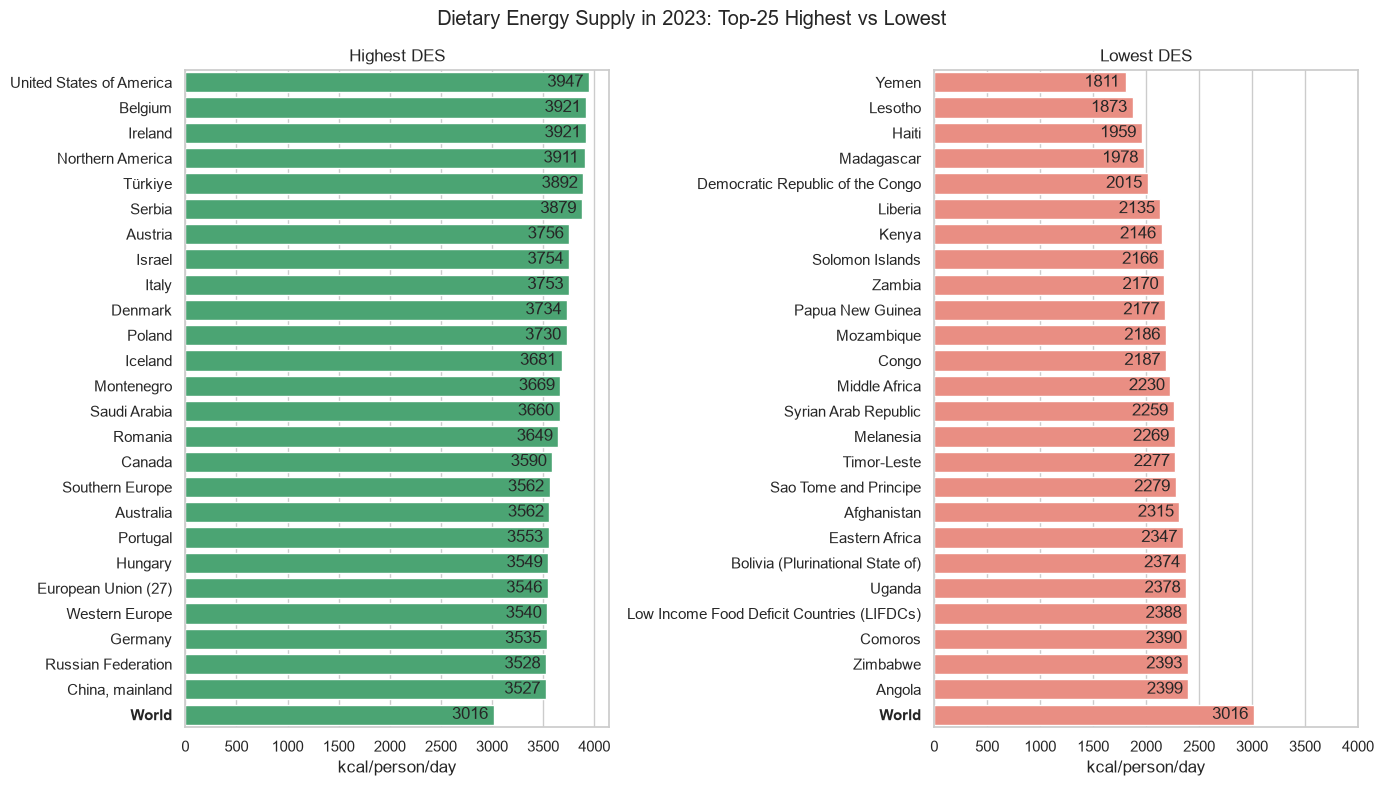

In [256]:
year_choice = 2023
edges = 25

q1_choice = q1[q1["year"] == year_choice]
top = pd.concat([q1_choice.head(edges).sort_values("des", ascending=False), q1_choice[q1_choice["area_name"] == "World"]])
bottom = pd.concat([q1_choice.tail(edges).sort_values("des"), q1_choice[q1_choice["area_name"] == "World"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.barplot(
    data=top,
    x="des",
    y="area_name",
    ax=axes[0],
    color="mediumseagreen"
)

axes[0].set_title("Highest DES")
axes[0].set_xlabel("kcal/person/day")
axes[0].set_ylabel("")
axes[0].bar_label(axes[0].containers[0], fmt="%.0f", padding=-30)
for label in axes[0].get_yticklabels():
    if label.get_text() == "World":
        label.set_fontweight("bold")

sns.barplot(
    data=bottom,
    x="des",
    y="area_name",
    ax=axes[1],
    color="salmon"
)

axes[1].set_title("Lowest DES")
axes[1].set_xlabel("kcal/person/day")
axes[1].set_ylabel("")
axes[1].bar_label(axes[1].containers[0], fmt="%.0f", padding=-30)
for label in axes[1].get_yticklabels():
    if label.get_text() == "World":
        label.set_fontweight("bold")

fig.suptitle(f"Dietary Energy Supply in {q1_choice["year"].unique()[0]}: Top-{edges} Highest vs Lowest")
plt.xticks(range(0, 4200, 500))
plt.tight_layout()
plt.show()

***Research question 2 - Which countries show the strongest increase or decline in DES over time?***

In [222]:
q2

,area_name,year,des
0,Afghanistan,2010,2200.21
1,Afghanistan,2011,2171.86
2,Afghanistan,2012,2165.88
3,Afghanistan,2013,2205.33
4,Afghanistan,2014,2270.45
...,...,...,...
2896,Zimbabwe,2019,2144.17
2897,Zimbabwe,2020,2240.20
2898,Zimbabwe,2021,2310.18
2899,Zimbabwe,2022,2319.40


In [235]:
start_year = q2["year"].min()
end_year = q2["year"].max()
q2_change = (q2[q2["year"].isin([start_year, end_year])].pivot(index="area_name",columns="year",values="des").dropna().reset_index())
q2_change["avg_annual_change"] = (q2_change[end_year] - q2_change[start_year]) / (end_year - start_year)
q2_change = q2_change.sort_values("avg_annual_change",ascending=False)

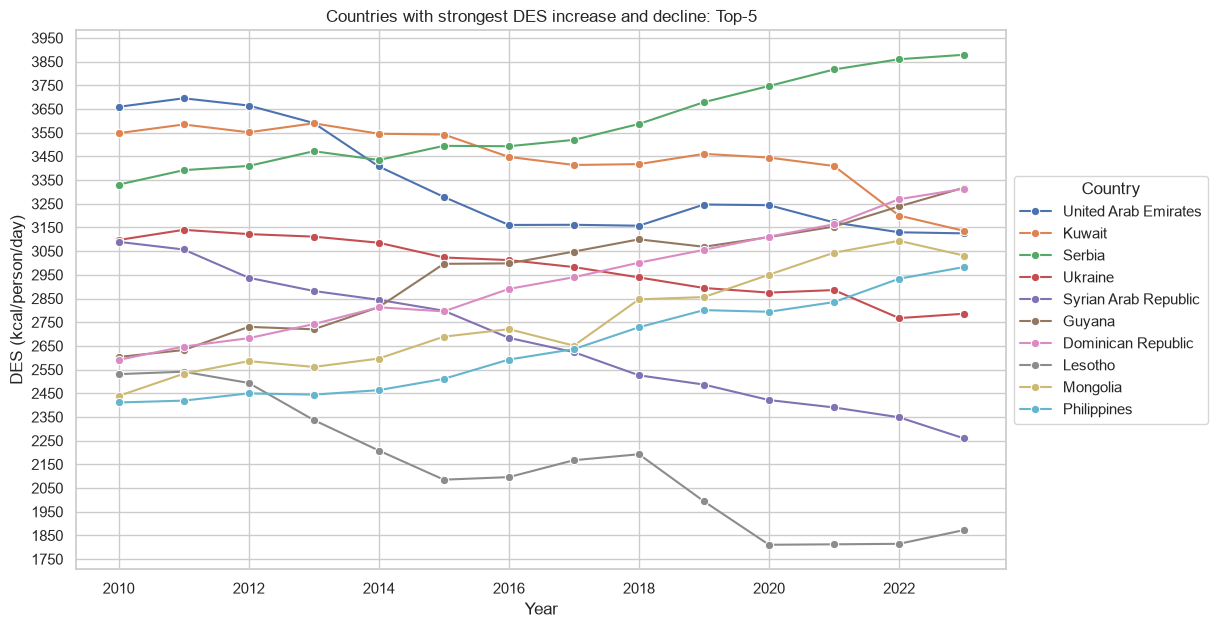

In [250]:
edges = 5

top = q2_change.head(edges)
bottom = q2_change.tail(edges)
countries_choice = pd.concat([top["area_name"], bottom["area_name"]])

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=q2[q2["area_name"].isin(countries_choice)],
    x="year",
    y="des",
    hue="area_name",
    marker="o"
)

plt.title(f"Countries with strongest DES increase and decline: Top-{edges}")
plt.xlabel("Year")
plt.ylabel("DES (kcal/person/day)")
plt.yticks(range(1750, 4000, 100))
plt.legend(title="Country",bbox_to_anchor=(1,0.5), loc="center left")

plt.show()

***Research question 3 - Which food products/groups contribute most to DES, and how does this composition differ by year?***

In [153]:
q3

,item_name,year,avg_des
0,Grand Total,2010,2855.866098
1,Vegetal Products,2010,2318.716537
2,Cereals - Excluding Beer,2010,1094.619268
3,Wheat and products,2010,545.645317
4,Animal Products,2010,537.149268
...,...,...,...
1671,"Fish, Liver Oil",2023,0.205857
1672,Cottonseed,2023,0.159268
1673,Cloves,2023,0.154265
1674,Sugar beet,2023,0.102239


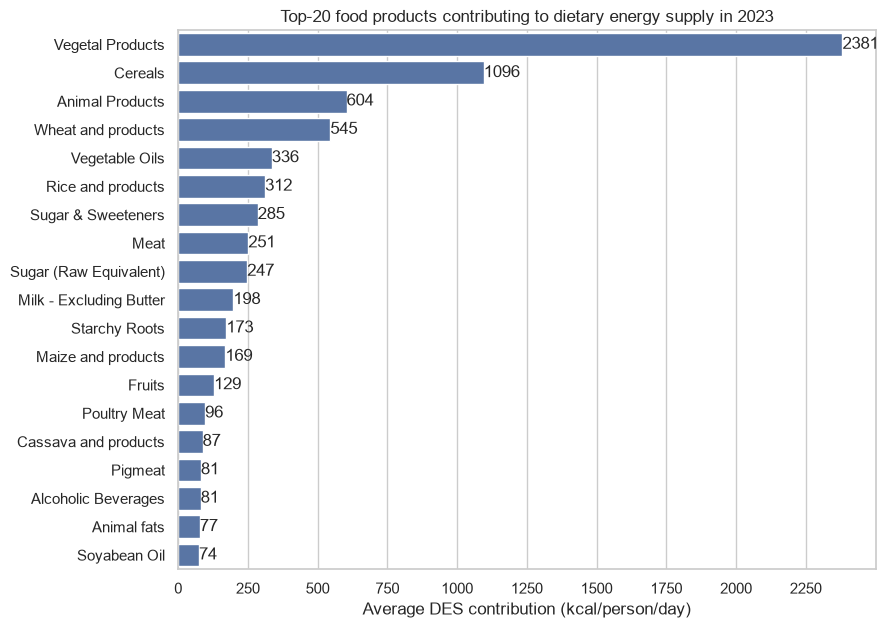

In [ ]:
year_choice = 2023
edges = 20

q3_plot = q3[q3["item_name"] != "Grand Total"]
q3_plot = q3_plot[q3_plot["year"] == year_choice].sort_values("avg_des", ascending=False).head(edges)

q3_plot["item_name"] = q3_plot["item_name"].replace({
    "Cereals - Excluding Beer": "Cereals",
    "Fruits - Excluding Wine": "Fruits"
})

plt.figure(figsize=(9, 7))
ax = sns.barplot(
    data=q3_plot,
    x="avg_des",
    y="item_name"
)
plt.bar_label(ax.containers[0], fmt="%.0f")
plt.xticks(range(0, 2500, 250))
plt.title(f"Top-{edges} food products contributing to dietary energy supply in {q3_plot["year"].unique()[0]}")
plt.xlabel("Average DES contribution (kcal/person/day)")
plt.ylabel("")
plt.show()

***Research question 4 - Which food products/groups show the strongest increase or decline in their contribution to DES over time?***

In [268]:
q4

,item_code,item_name,year,avg_des
0,2901,Grand Total,2010,2855.866098
1,2903,Vegetal Products,2010,2318.716537
2,2905,Cereals - Excluding Beer,2010,1094.619268
3,2511,Wheat and products,2010,545.645317
4,2941,Animal Products,2010,537.149268
...,...,...,...,...
1671,2782,"Fish, Liver Oil",2023,0.205857
1672,2559,Cottonseed,2023,0.159268
1673,2642,Cloves,2023,0.154265
1674,2537,Sugar beet,2023,0.102239


In [270]:
start_year = q4["year"].min()
end_year = q4["year"].max()
q4_change = (q4[q4["year"].isin([start_year, end_year])].pivot(index=["item_code", "item_name"],columns="year",values="avg_des").dropna().reset_index())
q4_change["avg_annual_change"] = (q4_change[end_year] - q4_change[start_year]) / (end_year - start_year)
q4_change = q4_change.sort_values("avg_annual_change",ascending=False)

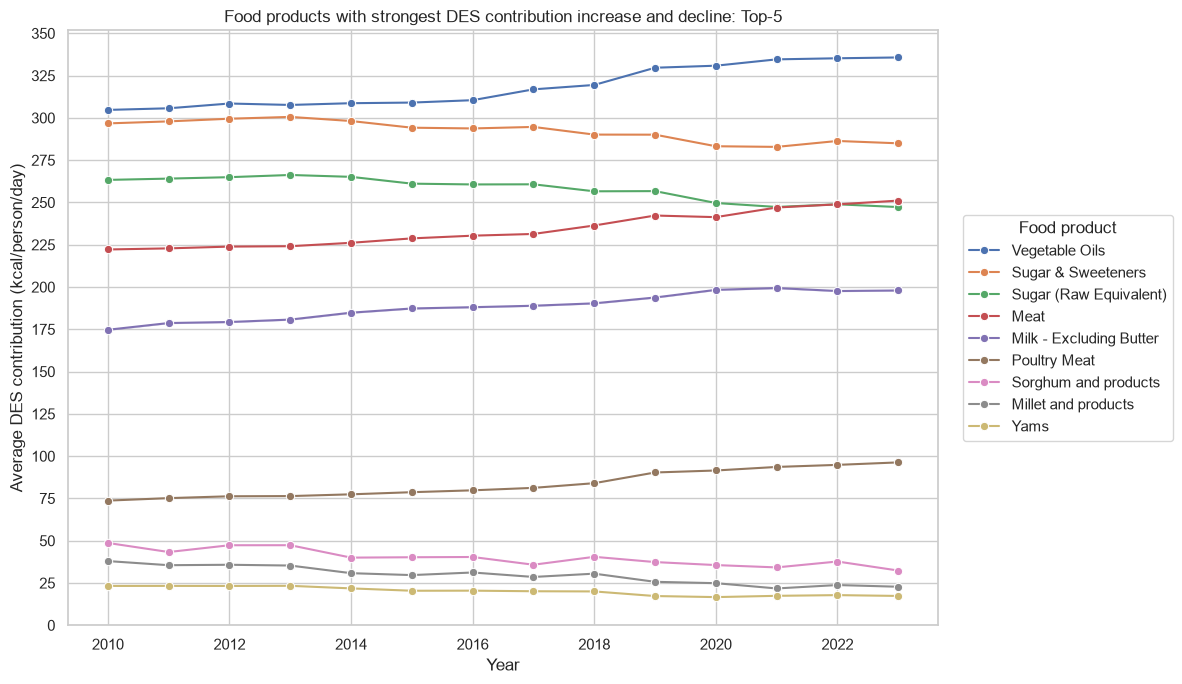

In [283]:
edges = 5

q4_change = q4_change[q4_change["item_name"] != "Grand Total"]
q4_change = q4_change[q4_change["item_name"] != "Vegetal Products"]
q4_change = q4_change[q4_change["item_name"] != "Animal Products"]

top = q4_change.head(edges)
bottom = q4_change.tail(edges)
products_choice = pd.concat([top["item_name"],bottom["item_name"]])

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=q4[q4["item_name"].isin(products_choice)],
    x="year",
    y="avg_des",
    hue="item_name",
    marker="o"
)

plt.title(
    f"Food products with strongest DES contribution increase and decline: Top-{edges}"
)
plt.xlabel("Year")
plt.ylabel("Average DES contribution (kcal/person/day)")

plt.legend(
    title="Food product",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)
plt.yticks(range(0, 375,25))
plt.tight_layout()
plt.show()

***Research question 5 - Does harvested agricultural area per person relate to dietary energy supply, and which countries have relatively high harvested area per person but low DES?***

In [ ]:
q5

,item_code,item_name,year,avg_des
0,2901,Grand Total,2010,2855.866098
1,2903,Vegetal Products,2010,2318.716537
2,2905,Cereals - Excluding Beer,2010,1094.619268
3,2511,Wheat and products,2010,545.645317
4,2941,Animal Products,2010,537.149268
...,...,...,...,...
1671,2782,"Fish, Liver Oil",2023,0.205857
1672,2559,Cottonseed,2023,0.159268
1673,2642,Cloves,2023,0.154265
1674,2537,Sugar beet,2023,0.102239


In [290]:
year_choice = 2023

q5_choice = q5[q5["year"] == year_choice]
fig = px.scatter(q5_choice,x="harvested_area_per_person",y="des",hover_name="area_name",
    title=f"Harvested area per person vs dietary energy supply in {year_choice}",
    labels={"harvested_area_per_person": "Harvested area (ha/person)","des": "DES (kcal/person/day)"},
    width=900,
    height=600,)
fig.show()

***Research question 6 - Which food product groups are most associated with rising imports and declining domestic production as GDP per capita grows?***

In [424]:
q6

,area_name,area_code,year,item_code,item_name,element_name,value,gdp_per_capita
0,Afghanistan,2,2010,2924,Alcoholic Beverages,Production,0.0,528.214980
1,Afghanistan,2,2010,2924,Alcoholic Beverages,Import quantity,3.0,528.214980
2,Afghanistan,2,2011,2924,Alcoholic Beverages,Production,0.0,549.142823
3,Afghanistan,2,2011,2924,Alcoholic Beverages,Import quantity,3.0,549.142823
4,Afghanistan,2,2012,2924,Alcoholic Beverages,Production,0.0,580.640581
...,...,...,...,...,...,...,...,...
91538,Zimbabwe,181,2021,2918,Vegetables,Import quantity,4.0,1310.529669
91539,Zimbabwe,181,2022,2918,Vegetables,Production,2018.0,1366.847475
91540,Zimbabwe,181,2022,2918,Vegetables,Import quantity,5.0,1366.847475
91541,Zimbabwe,181,2023,2918,Vegetables,Production,2315.0,1416.476148


In [425]:
q6_pivot = q6.pivot_table(index=["area_code","area_name","year","item_code","item_name","gdp_per_capita"],columns="element_name",values="value").reset_index()
q6_pivot = q6_pivot.rename(columns={"Production": "production","Import quantity": "imports"})

start_year = q6_pivot["year"].min()
q6_start = q6_pivot[q6_pivot["year"] == start_year]
end_year = q6_pivot["year"].max()
q6_end = q6_pivot[q6_pivot["year"] == end_year]

q6_period = q6_start.merge(q6_end,on=["area_code", "area_name", "item_code", "item_name"],suffixes=("_start", "_end"))
q6_period = q6_period[(q6_period["imports_start"] > 0) & (q6_period["production_start"] > 0)].copy()

q6_period["gdp_change_pct"] = ((q6_period["gdp_per_capita_end"] - q6_period["gdp_per_capita_start"])/ q6_period["gdp_per_capita_start"] * 100)
q6_period["import_change_pct"] = ((q6_period["imports_end"] - q6_period["imports_start"]) / q6_period["imports_start"] * 100)
q6_period["production_change_pct"] = ((q6_period["production_end"] - q6_period["production_start"]) / q6_period["production_start"] * 100)

q6_period = q6_period[q6_period["item_name"] != "Miscellaneous"]

product_counts = q6_period["item_name"].value_counts()
product_counts

item_name
Vegetables                  164
Fruits - Excluding Wine     162
Fish, Seafood               159
Milk - Excluding Butter     158
Meat                        155
Starchy Roots               154
Cereals - Excluding Beer    152
Alcoholic Beverages         149
Vegetable Oils              147
Sugar & Sweeteners          140
Oilcrops                    137
Animal fats                 131
Pulses                      127
Eggs                        102
Offals                       91
Treenuts                     79
Spices                       67
Stimulants                   64
Aquatic Products, Other      18
Sugar Crops                  17
Name: count, dtype: int64

In [426]:
q6_corr = q6_period.groupby("item_name")[["gdp_change_pct", "import_change_pct", "production_change_pct"]].corr().reset_index()
q6_corr = q6_corr[q6_corr["element_name"] == "gdp_change_pct"]
q6_corr = q6_corr[["item_name","import_change_pct","production_change_pct"]]
q6_corr = q6_corr.rename(columns={"import_change_pct": "gdp_import_corr","production_change_pct": "gdp_production_corr"})
q6_corr

element_name,item_name,gdp_import_corr,gdp_production_corr
0,Alcoholic Beverages,0.014322,0.109150
3,Animal fats,0.089872,0.043464
6,"Aquatic Products, Other",0.426840,-0.141080
9,Cereals - Excluding Beer,0.143642,0.063832
12,Eggs,0.008630,-0.067319
15,"Fish, Seafood",0.220180,0.169313
18,Fruits - Excluding Wine,0.161906,0.270198
21,Meat,0.120434,0.313131
24,Milk - Excluding Butter,0.127708,0.260803
27,Offals,-0.070118,0.013458


In [ ]:
import_p = []
production_p = []

for product in q6_corr["item_name"]:
    data = q6_period[q6_period["item_name"] == product]
    import_p.append(pearsonr(data["gdp_change_pct"],data["import_change_pct"]).pvalue)
    production_p.append(pearsonr(data["gdp_change_pct"],data["production_change_pct"]).pvalue)
q6_corr["gdp_import_p"] = import_p
q6_corr["gdp_production_p"] = production_p

q6_corr["gdp_import_p"] = np.where(q6_corr["gdp_import_p"] < 0.05,"Significant","-")
q6_corr["gdp_production_p"] = np.where(q6_corr["gdp_production_p"] < 0.05,"Significant","-")

q6_corr

element_name,item_name,gdp_import_corr,gdp_production_corr,gdp_import_p,gdp_production_p
0,Alcoholic Beverages,0.014322,0.109150,-,-
3,Animal fats,0.089872,0.043464,-,-
6,"Aquatic Products, Other",0.426840,-0.141080,-,-
9,Cereals - Excluding Beer,0.143642,0.063832,-,-
12,Eggs,0.008630,-0.067319,-,-
15,"Fish, Seafood",0.220180,0.169313,Significant,Significant
18,Fruits - Excluding Wine,0.161906,0.270198,Significant,Significant
21,Meat,0.120434,0.313131,-,Significant
24,Milk - Excluding Butter,0.127708,0.260803,-,Significant
27,Offals,-0.070118,0.013458,-,-


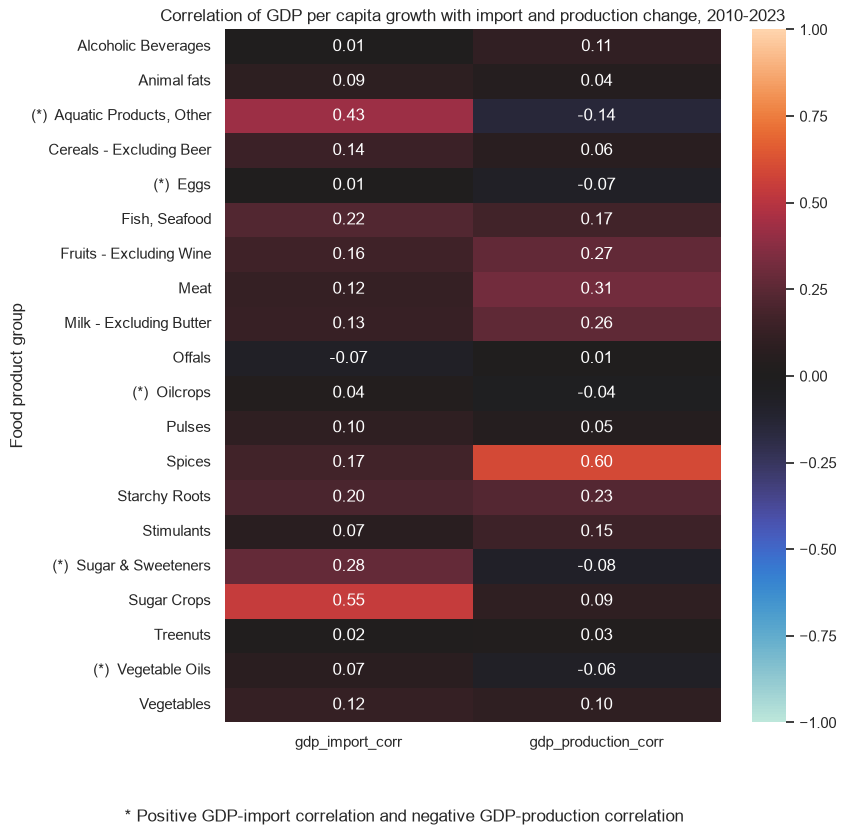

In [ ]:
q6_corr["label"] = np.where((q6_corr["gdp_import_corr"] > 0) & (q6_corr["gdp_production_corr"] < 0),  "(*)  " + q6_corr["item_name"], q6_corr["item_name"])

q6_heatmap = q6_corr.set_index("label")[["gdp_import_corr", "gdp_production_corr"]]
plt.figure(figsize=(8, 9))
sns.heatmap(q6_heatmap,annot=True,fmt=".2f",vmin=-1, vmax=1, center=0)
plt.title(f"Correlation of GDP per capita growth with import and production change, {start_year}-{end_year}")
plt.xlabel("")
plt.figtext(0,0,"* Positive GDP-import correlation and negative GDP-production correlation", ha="left")
plt.show()

---
## 5. Conclusions

1. DES varies substantially across countries and regions, confirming clear differences in food availability.

2. DES trends differ strongly by country, with some showing substantial increases and others clear declines.

3. Vegetal products and particularly cereals make the largest contribution to average DES.

4. Vegetable oils, meat and milk show notable increases in DES contribution, while several sugar and grain products decline.

5. Harvested area per person does not show a clear strong relationship with DES, suggesting that land availability alone does not explain dietary energy supply.

6. Only a few food groups show the expected combination of rising imports and declining production as GDP per capita grows, and most correlations are weak.

7. Each of results/visualizations suggests significant potential for additional analysis and deeper investigation.

---
## 6. Limitations and next steps

Limitations:

Question 6 - Pearson correlations were calculated across countries using percentage changes from 2010 to 2023. Percentage changes can become extreme when the starting value is very small.



Next steps: 

Improve and expand the visualizations in Tableau